# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

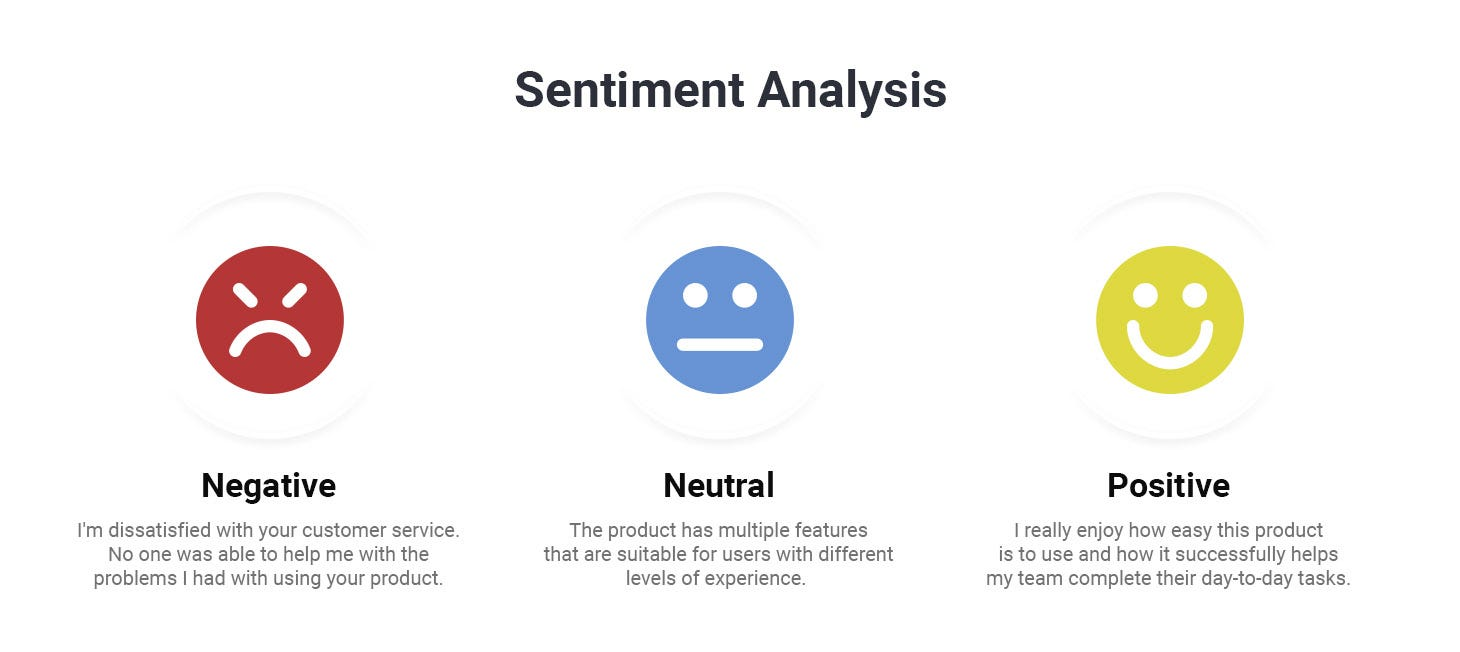

# Disneyland Reviews Dataset
In this lab we'll look into Disneyland Reviews dataset.  
*Link: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews*

The dataset includes 42,000 reviews of 3 Disneyland branches - Paris, California and Hong Kong, posted by visitors on Trip Advisor.

Column Description:

- Review_ID: unique id given to each review
- Rating: ranging from 1 (unsatisfied) to 5 (satisfied)
- Year_Month: when the reviewer visited the theme park
- Reviewer_Location: country of origin of visitor
- Review_Text: comments made by visitor
- Disneyland_Branch: location of Disneyland Park

In [ ]:
# Load the dataset
import pandas as pd

data = pd.read_csv('/content/DisneylandReviews.csv', encoding='latin-1')
data

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong
...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris


In [ ]:
#Check for missing values
data.isna().sum()

,0
Review_ID,0
Rating,0
Year_Month,0
Reviewer_Location,0
Review_Text,0
Branch,0


In [ ]:
# Drop rows with missing values in the relevant columns
data = data.dropna(subset=['Review_Text', 'Rating'])

In [ ]:
# Map star ratings to sentiments
data['Sentiment'] = data['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))
data.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,Sentiment
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,positive
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,positive
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,positive
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,positive
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,positive


In [ ]:
# Import necessary libraries
import re
import nltk

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize the text
    words = text.split()

    return ' '.join(words)

# Apply preprocessing to the review text
data['Review_Text'] = data['Review_Text'].apply(preprocess_text)

# Display cleaned reviews
data[['Review_Text', 'Sentiment']].head()

,Review_Text,Sentiment
0,if youve ever been to disneyland anywhere youl...,positive
1,its been a while since d last time we visit hk...,positive
2,thanks god it wasn t too hot or too humid when...,positive
3,hk disneyland is a great compact park unfortun...,positive
4,the location is not in the city took around ho...,positive


In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the dataset into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(data['Review_Text'], data['Sentiment'], test_size=0.2, random_state=42)


# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # You can adjust max_features based on your dataset size - limit vocabulary to the 1000 most informative tokens
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

In [ ]:
print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

train_data size: (34124,)
test_data size: (8532,)


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train the Support Vector Machine (SVM) classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(train_vectors, train_labels)

# Predictions on the test set
predictions = svm_classifier.predict(test_vectors)

# Evaluate the model
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))


Accuracy: 0.84
Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.54      0.58       720
     neutral       0.48      0.18      0.26      1035
    positive       0.88      0.98      0.92      6777

    accuracy                           0.84      8532
   macro avg       0.66      0.56      0.59      8532
weighted avg       0.81      0.84      0.81      8532



# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

In [4]:
import re
import html
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Load the data
df = pd.read_csv(r"C:\Users\moham\Documents\Codex\2026-10-04\modulenotfounderror-traceback-most-recent-call-last\work\lab4_data\Amazon_Unlocked_Mobile.csv",
low_memory=False
)

df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df = df.dropna(subset=["Reviews", "Rating"])
df = df[df["Rating"].isin([1, 2, 3, 4, 5])].copy()

# Create sentiment labels
def rating_to_sentiment(rating):
    if rating > 3:
        return "positive"
    elif rating < 3:
        return "negative"
    return "neutral"

df["Sentiment"] = df["Rating"].map(rating_to_sentiment)

# Keep negation words because they affect sentiment
negation_words = {"no", "nor", "not", "never", "nothing", "neither", "cannot"}
stop_words = set(ENGLISH_STOP_WORDS) - negation_words

html_pattern = re.compile(r"<[^>]+>")
email_pattern = re.compile(r"\b[\w.+-]+@[\w.-]+\.[a-z]{2,63}\b", re.I)
url_pattern = re.compile(
    r"(?:https?://|www\.)\S+|"
    r"\b(?:[a-z0-9-]+\.)+[a-z]{2,63}\b(?:[/?:#]\S*)?",
    re.I
)

def preprocess(text):
    # 1. Normalize text, lowercase, and expand negative contractions
    text = unicodedata.normalize("NFKC", html.unescape(str(text))).lower()
    text = re.sub(r"\bwon['’]t\b", "will not", text)
    text = re.sub(r"\bcan['’]t\b", "can not", text)
    text = re.sub(r"n['’]t\b", " not", text)

    # 2. Remove HTML, emails, and websites
    text = html_pattern.sub(" ", text)
    text = email_pattern.sub(" ", text)
    text = url_pattern.sub(" ", text)

    # 3. Remove punctuation, numbers, and special characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # 4. Tokenize
    tokens = text.split()

    # 5. Remove stop words and normalize whitespace
    return " ".join(word for word in tokens if word not in stop_words)

df["Clean_Review"] = df["Reviews"].map(preprocess)

# Remove empty reviews
df = df[df["Clean_Review"].str.len() > 0].copy()

# Remove identical cleaned reviews with conflicting labels
label_counts = df.groupby("Clean_Review")["Sentiment"].transform("nunique")
df = df[label_counts.eq(1)].copy()

# Remove duplicates to prevent the same review appearing in both splits
df = df.drop_duplicates("Clean_Review").reset_index(drop=True)

print("Usable reviews:", len(df))
print(df["Sentiment"].value_counts())

display(df[["Reviews", "Clean_Review", "Sentiment"]].head())

Usable reviews: 152015
Sentiment
positive    94993
negative    43137
neutral     13885
Name: count, dtype: int64


,Reviews,Clean_Review,Sentiment
0,I feel so LUCKY to have found this used (phone...,feel lucky used phone not used hard phone line...,positive
1,"nice phone, nice up grade from my pantach revu...",nice phone nice grade pantach revue clean set ...,positive
2,It works good but it goes slow sometimes but i...,works good goes slow good phone love,positive
3,Great phone to replace my lost phone. The only...,great phone replace lost phone thing volume bu...,positive
4,I already had a phone with problems... I know ...,phone problems know stated used dang did not s...,negative


In [5]:
from sklearn.model_selection import train_test_split

X = df["Clean_Review"]
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

assert set(X_train).isdisjoint(set(X_test))

print("Training reviews:", len(X_train))
print("Test reviews:", len(X_test))

Training reviews: 121612
Test reviews: 30403


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
    dtype=np.float32
)

# Learn vocabulary and IDF from training data only
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Training shape: (121612, 30000)
Test shape: (30403, 30000)


In [7]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB(alpha=1.0)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Model trained successfully.")

Model trained successfully.


In [8]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)

labels = ["negative", "neutral", "positive"]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_test, y_pred, average='weighted'):.4f}")

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred,
    labels=labels,
    digits=4,
    zero_division=0
))

Accuracy: 83.23%
Balanced accuracy: 0.5996
Macro F1: 0.5787
Weighted F1: 0.7946

Classification report:
              precision    recall  f1-score   support

    negative     0.7818    0.8319    0.8061      8627
     neutral     0.4713    0.0148    0.0286      2777
    positive     0.8557    0.9520    0.9013     18999

    accuracy                         0.8323     30403
   macro avg     0.7029    0.5996    0.5787     30403
weighted avg     0.7996    0.8323    0.7946     30403



Confusion matrix:


,Predicted negative,Predicted neutral,Predicted positive
Actual negative,7177,17,1433
Actual neutral,1120,41,1616
Actual positive,883,29,18087


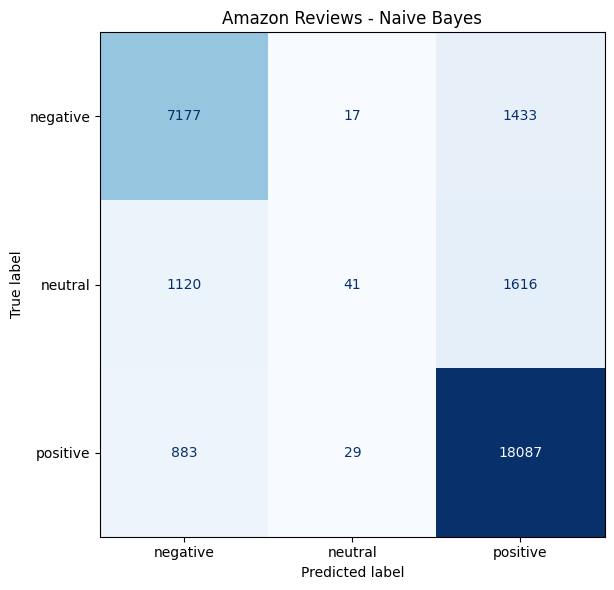

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=labels)

print("Confusion matrix:")
display(pd.DataFrame(
    cm,
    index=[f"Actual {label}" for label in labels],
    columns=[f"Predicted {label}" for label in labels]
))

fig, ax = plt.subplots(figsize=(7.5, 6))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
).plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

ax.set_title("Amazon Reviews - Naive Bayes")
plt.tight_layout()
plt.show()